In [ ]:
# ! pip install glasbey
# ! pip install nimfa
# ! pip install seqnmf

In [38]:
! pip install --upgrade seqnmf

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

import glasbey

from nimfa import Nmf                 # standard NMF
from seqnmf import seqnmf, plot, example_data

In [ ]:
filename = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\combined_matrix_2lc.csv'
data = pd.read_csv( filename , index_col=0)

grouped_filename = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\cluster_groups_matlab.csv'
groups = pd.read_csv( grouped_filename )

In [ ]:
def map_grouped_clusters(df):
    return df.merge(groups[['Cluster', 'Group']], left_on='Cluster', right_on='Cluster', how='left')


new_data = map_grouped_clusters( data )

In [33]:
data = data[data["Week_Number"] == 18] 
data

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30,Timestamp,Cluster,Week_Number
95989,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,...,0.083333,0.566667,0.300000,0.050000,0.0,0.000000,1.000000,40990.0498,5,18
95990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.100000,0.900000,...,0.133333,0.450000,0.216667,0.200000,0.0,0.016667,0.983333,40990.3898,18,18
95991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,...,0.066667,0.516667,0.300000,0.066667,0.0,0.016667,0.983333,40990.7348,27,18
95992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,...,0.216667,0.250000,0.300000,0.216667,0.0,0.000000,1.000000,40991.0998,87,18
95993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.883333,0.116667,...,0.066667,0.283333,0.450000,0.116667,0.0,0.016667,0.983333,40991.4448,87,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,...,0.083333,0.483333,0.416667,0.016667,0.0,0.066667,0.933333,49786.8398,27,18
120976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,...,0.066667,0.350000,0.400000,0.183333,0.0,0.000000,1.000000,49787.2048,27,18
120977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.600000,0.400000,...,0.033333,0.483333,0.250000,0.133333,0.0,0.000000,1.000000,49787.5498,87,18
120978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000,...,0.183333,0.150000,0.333333,0.216667,0.0,0.000000,1.000000,49787.8948,50,18


In [43]:
print(type(example_data))
print(example_data.shape)
print(example_data[:5, :10])  # first 5 features, first 10 time points
print("Min:", example_data.min())
print("Max:", example_data.max())
print("Mean:", example_data.mean())

<class 'numpy.ndarray'>
(75, 666)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.03923955 0.26828702 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.20675668 0.        ]
 [0.         0.         0.         0.         0.         0.40430667
  0.5719485  0.31741695 0.16335899 0.08911339]]
Min: 0.0
Max: 0.9497805351065163
Mean: 0.018612182368358807


In [ ]:
[W, H, cost, loadings, power] = seqnmf(example_data, K=20, L=100, Lambda=0.001, plot_it=True)

plot(W, H).show()

**NNMF and SNNMF**

Data shape for seqNMF: (30, 24950)
Standard NMF components shape: (30, 5)
Standard NMF loading shape: (5, 24950)


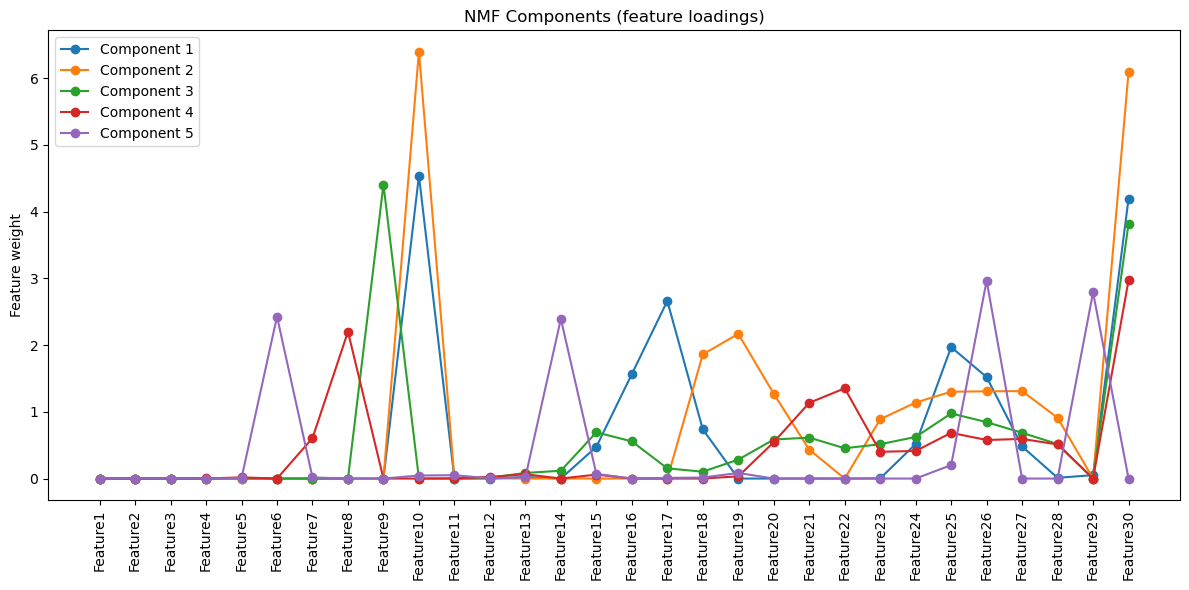

In [36]:
# Identify your 30 behavioral feature columns
feature_cols = [col for col in data.columns if col.startswith("Feature")]

# Optional: sort by time / disease progression (VERY important for seqNMF)
# df = df.sort_values("Week_Number")    # or "Timestamp" if finer resolution

# Extract feature matrix
X = data[feature_cols].values  
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X).T  

print("Data shape for seqNMF:", X_scaled.shape)

# Standard NMF using nimfa
nmf_model = Nmf(X_scaled, rank=5, max_iter=300, update='euclidean')
nmf_fit = nmf_model()

W = nmf_fit.basis()   # components
H = nmf_fit.coef()    # activations

print("Standard NMF components shape:", W.shape)
print("Standard NMF loading shape:", H.shape)

plt.figure(figsize=(12,6))
for k in range(W.shape[1]):
    plt.plot(W[:, k], marker='o', label=f"Component {k+1}")

plt.xticks(np.arange(len(feature_cols)), feature_cols, rotation=90)
plt.ylabel("Feature weight")
plt.title("NMF Components (feature loadings)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_H = pd.DataFrame(H.T, columns=[f"Component_{i+1}" for i in range(H.shape[0])])
df_H['Cluster'] = data['Cluster'].values

cluster_means = df_H.groupby("Cluster").mean()
cluster_means

cluster_means.plot(kind="bar", figsize=(12,6))
plt.ylabel("Average component activation")
plt.title("NMF component activation by cluster")
plt.show()

In [ ]:
df_H

**PCA**

In [ ]:
# Automatically find the number of stages
weeks = data['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

# Automatically find the total number of clusters
num_clusters = data['Cluster'].max()

# Automatically find the total number of groups
num_groups = data['Group'].max()

# Get all clusters present across the ENTIRE dataset
all_clusters = sorted(data['Cluster'].unique())
cluster_labels_str = [str(c) for c in all_clusters]

# Get all groups present across the ENTIRE dataset
all_groups = sorted(data['Group'].unique())
group_labels_str = [str(c) for c in all_groups]

# Create color pallette
glasbey_palette = glasbey.create_palette(palette_size=num_clusters)
cluster_to_color = {
    str(c): glasbey_palette[i % num_clusters]
    for i, c in enumerate(all_clusters)
}

In [ ]:
# --- Define features ---
feature_cols = [f"Feature{i}" for i in range(1, 31)]  

# --- Plot PCA for each week separately ---
weeks = sorted(data['Week_Number'].unique())

for week in weeks:
    week_data = data[data['Week_Number'] == week].copy()
    
    # Extract features for this week
    X = week_data[feature_cols].values
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Run PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(X_scaled)
    week_data['PCA1'] = pca_result[:, 0]
    week_data['PCA2'] = pca_result[:, 1]
    
    # Print explained variance for this week
    print(f"Week {week} - Explained variance ratio for first 2 components:", pca.explained_variance_ratio_)
    print(f"Week {week} - Total variance explained by first 2 components:", pca.explained_variance_ratio_.sum())
    
    # Map cluster colors (same Glasbey palette)
    # week_data['cluster_str'] = week_data['Cluster'].astype(str)
    # week_data['color'] = week_data['cluster_str'].map(cluster_to_color)
    
    week_data['group_str'] = week_data['Group'].astype(str)
    week_data['color'] = week_data['group_str'].map(cluster_to_color)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(
        week_data['PCA1'],
        week_data['PCA2'],
        c=week_data['color'],
        s=50,
        alpha=0.7
    )
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA of Features Colored by Cluster - Week {week}")
    
    # Optional legend (first 20 clusters for readability)
    # unique_clusters = sorted(week_data['cluster_str'].unique())
    unique_groups = sorted(week_data['group_str'].unique())
    
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_to_color[c], markersize=6)
        for c in unique_groups[:20]
    ]
    labels = unique_groups[:20]
    plt.legend(handles, labels, title="Cluster (first 20)", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()


In [ ]:
for week in weeks:
    week_data = data[data['Week_Number'] == week].copy()
    
    # Extract features
    X = week_data[feature_cols].values
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Run PCA
    pca = PCA(n_components=20)
    pca_result = pca.fit_transform(X_scaled)
    week_data['PCA1'] = pca_result[:, 0]
    week_data['PCA2'] = pca_result[:, 1]
    
    # Map cluster colors (using Glasbey)
    week_data['cluster_str'] = week_data['Group'].astype(str)
    week_data['color'] = week_data['cluster_str'].map(cluster_to_color)
    
    # --- Biplot ---
    plt.figure(figsize=(12, 8))
    
    # Plot scores (samples)
    # plt.scatter(
    #     week_data['PCA1'],
    #     week_data['PCA2'],
    #     c=week_data['color'],
    #     s=50,
    #     alpha=0.7
    # )
    
    # Plot feature vectors (loadings)
    loadings = pca.components_.T  # shape: n_features x 2
    for i, feature in enumerate(feature_cols):
        plt.arrow(0, 0, 
                  loadings[i, 0]*3,  # scale factor for visibility
                  loadings[i, 1]*3, 
                  color='red', 
                  alpha=0.7, 
                  head_width=0.1)
        plt.text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, feature, color='red', fontsize=9)
    
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.title(f"Biplot of Week {week}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Scree plot
    # plt.figure(figsize=(8, 5))

    # var_exp = pca.explained_variance_ratio_
    # cum_var_exp = var_exp.cumsum()

    # components = range(1, len(var_exp) + 1)

    # # Bars
    # plt.bar(components, var_exp, alpha=0.7, label='Individual explained variance')

    # # Cumulative line
    # plt.plot(components, cum_var_exp, marker='o', color='red', label='Cumulative explained variance')

    # plt.xticks(components)
    # plt.ylabel("Explained Variance Ratio")
    # plt.xlabel("Principal Component")
    # plt.title(f"Variance Explained by PCA Components – Week {week}")
    # plt.grid(True, linestyle='--', alpha=0.5)
    # plt.legend()
    # plt.tight_layout()
    # plt.show()



In [44]:
import pandas as pd

filename = r"Y:\Members\Mia-Sanjana-Hadent\Processed Data\wildtype_062425_011725_9\Altogether Clustering\Cluster_detail_results.csv"
df = pd.read_csv( filename )

df

,ClusterIdx,Timestamp,Folder_Name
0,1,117.2237,1_3d_arenah
1,1,117.5240,1_3d_arenah
2,1,117.8243,1_3d_arenah
3,1,118.1247,1_3d_arenah
4,1,118.7253,1_3d_arenah
...,...,...,...
119222,54,41031.1065,5_restricted_arena
119223,54,41031.4715,5_restricted_arena
119224,54,41031.8065,5_restricted_arena
119225,54,41032.1515,5_restricted_arena
